<a href="https://www.kaggle.com/code/sonawanelalitsunil/customer-purchase-behaviour-analysis-eda-83-3?scriptVersionId=269794930" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-purchase-behaviour/shopping_behavior_updated.csv


## Customer Purchase Behaviour Analysis

## Description (Detailed):
This dataset provides insights into how customers make purchasing decisions across various products and categories. It includes data on customer demographics, buying frequency, spending patterns, preferred payment methods, and product preferences. By analyzing these factors, we can uncover trends in customer behavior, identify high-value customer segments, and predict future purchase tendencies. Such analysis helps businesses optimize marketing strategies, personalize recommendations, and improve customer retention through data-driven insights.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/customer-purchase-behaviour/shopping_behavior_updated.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

Customer ID               3900
Age                         53
Gender                       2
Item Purchased              25
Category                     4
Purchase Amount (USD)       81
Location                    50
Size                         4
Color                       25
Season                       4
Review Rating               26
Subscription Status          2
Shipping Type                6
Discount Applied             2
Promo Code Used              2
Previous Purchases          50
Payment Method               6
Frequency of Purchases       7
dtype: int64

In [10]:
df.shape

(3900, 18)

In [11]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [12]:
df.describe().loc[['mean','min','max']]

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
mean,1950.5,44.068462,59.764359,3.749949,25.351538
min,1.0,18.000000,20.000000,2.500000,1.000000
max,3900.0,70.000000,100.000000,5.000000,50.000000


In [13]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

## Data visualizations

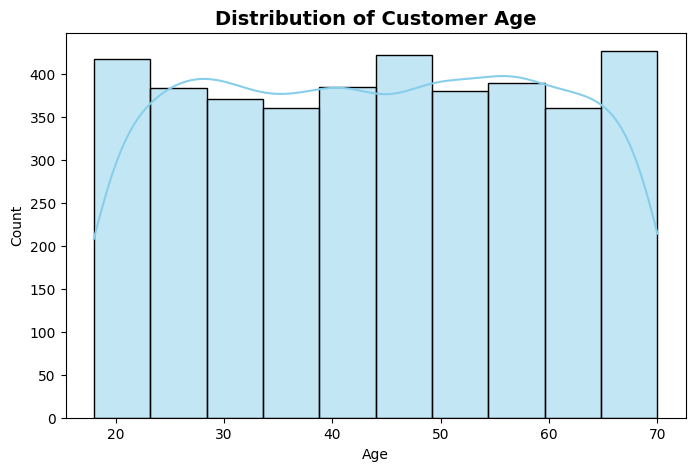

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Customer Age', fontsize=14, weight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

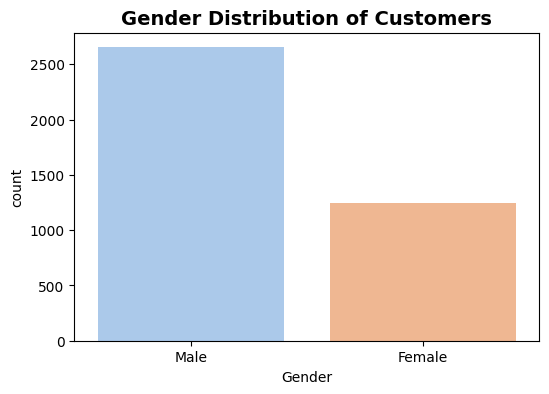

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Gender Distribution of Customers', fontsize=14, weight='bold')
plt.show()

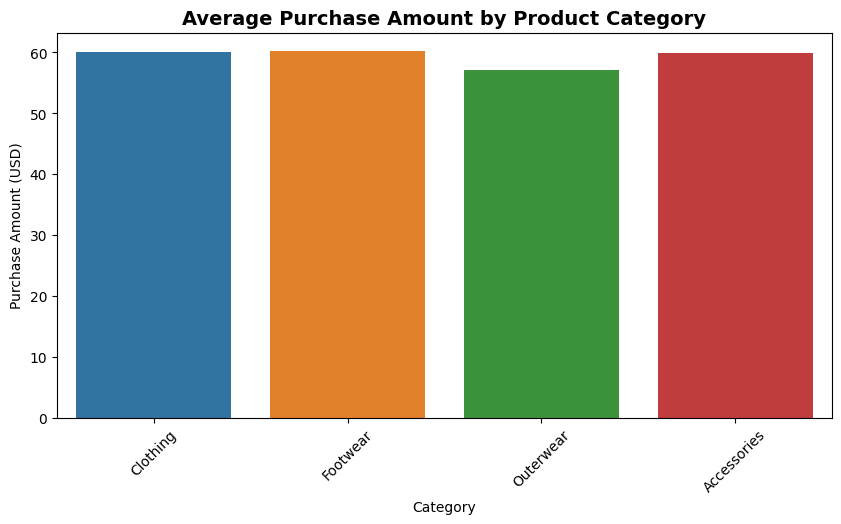

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Category', y='Purchase Amount (USD)', ci=None)
plt.title('Average Purchase Amount by Product Category', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.show()


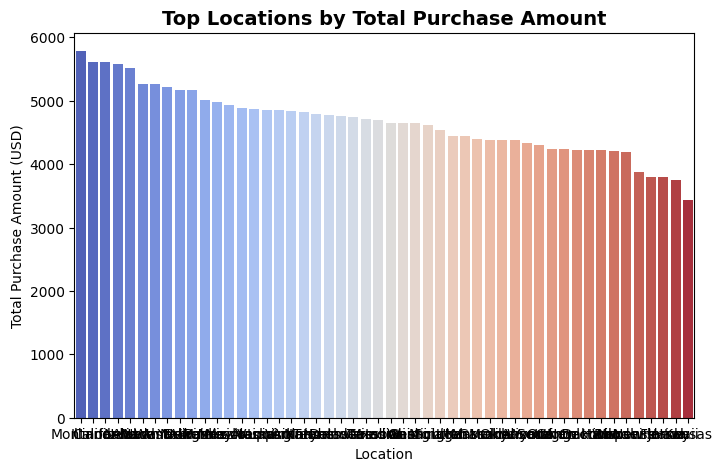

In [17]:
top_locations = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=top_locations.index, y=top_locations.values, palette='coolwarm')
plt.title('Top Locations by Total Purchase Amount', fontsize=14, weight='bold')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

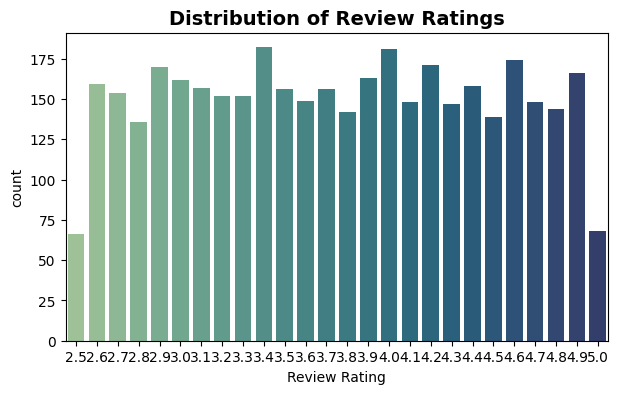

In [18]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Review Rating', palette='crest')
plt.title('Distribution of Review Ratings', fontsize=14, weight='bold')
plt.show()

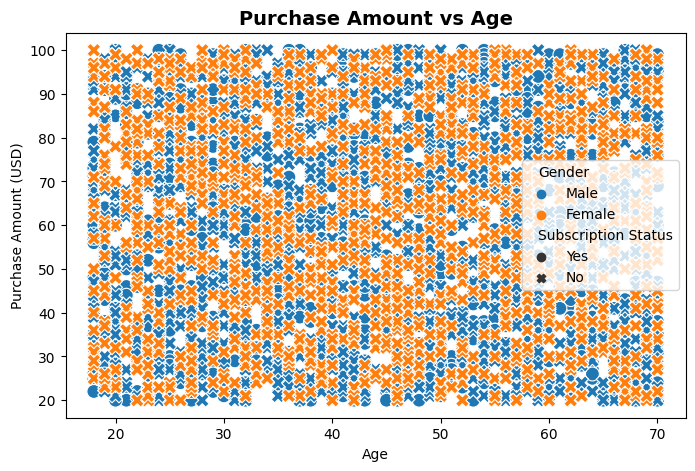

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Purchase Amount (USD)', hue='Gender', style='Subscription Status', s=100)
plt.title('Purchase Amount vs Age', fontsize=14, weight='bold')
plt.show()


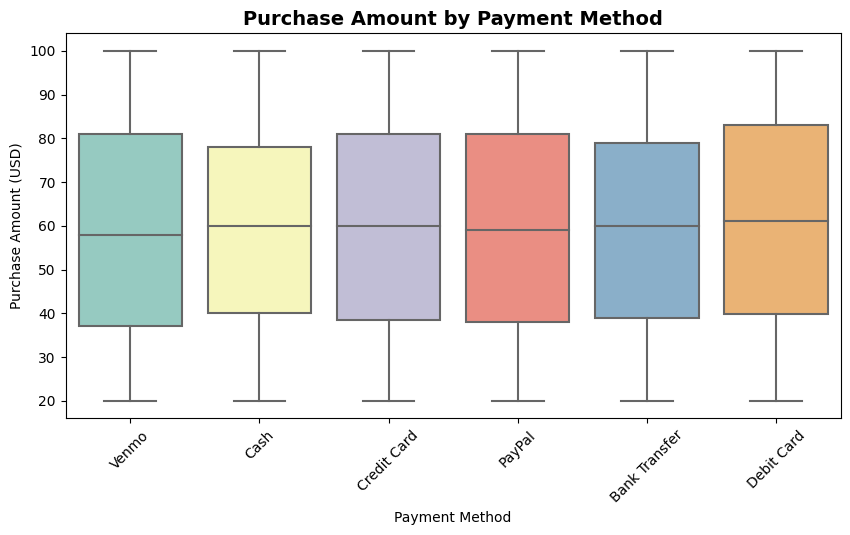

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Payment Method', y='Purchase Amount (USD)', palette='Set3')
plt.title('Purchase Amount by Payment Method', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.show()


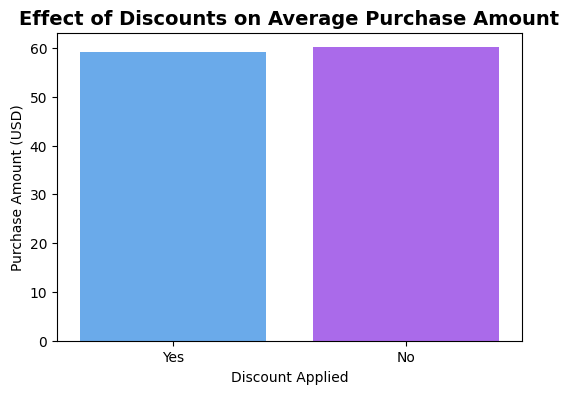

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Discount Applied', y='Purchase Amount (USD)', estimator='mean', ci=None, palette='cool')
plt.title('Effect of Discounts on Average Purchase Amount', fontsize=14, weight='bold')
plt.show()

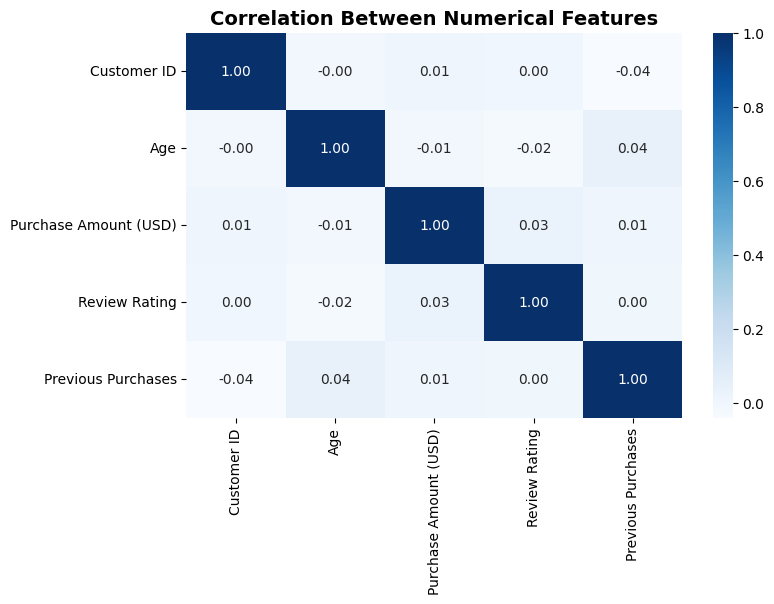

In [22]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Numerical Features', fontsize=14, weight='bold')
plt.show()

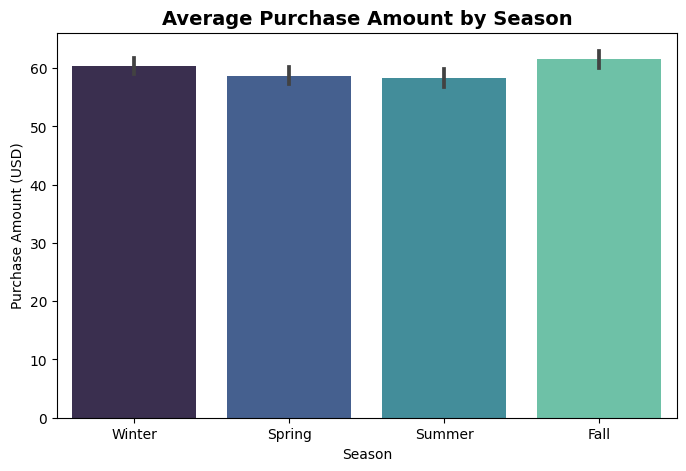

In [23]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Season', y='Purchase Amount (USD)', palette='mako')
plt.title('Average Purchase Amount by Season', fontsize=14, weight='bold')
plt.show()

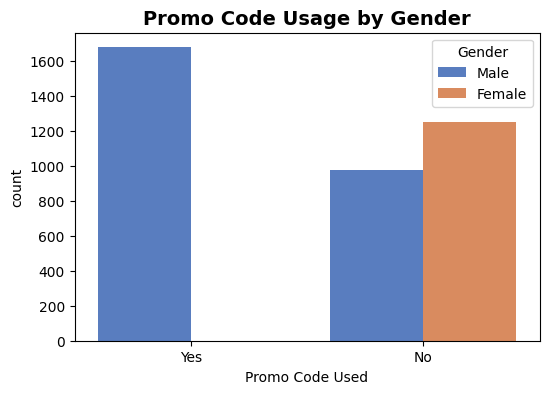

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Promo Code Used', hue='Gender', palette='muted')
plt.title('Promo Code Usage by Gender', fontsize=14, weight='bold')
plt.show()

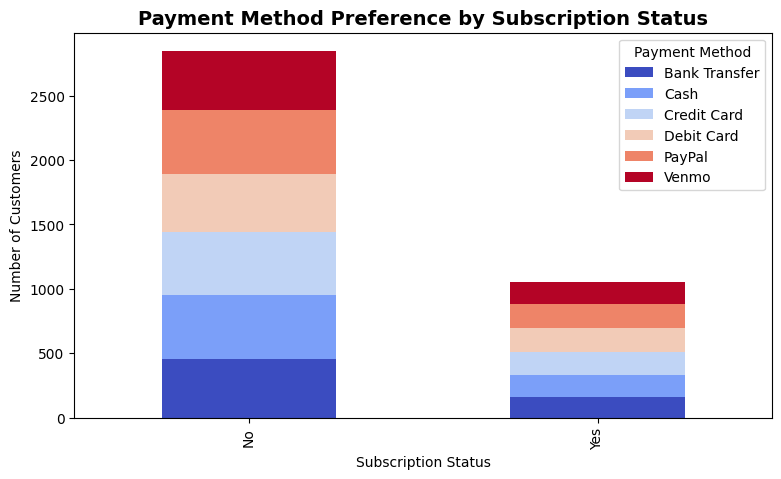

In [25]:
payment_counts = df.groupby(['Subscription Status','Payment Method']).size().unstack()
payment_counts.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(9,5))
plt.title('Payment Method Preference by Subscription Status', fontsize=14, weight='bold')
plt.ylabel('Number of Customers')
plt.show()

## ML Algorithms

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [27]:
X = df.drop(['Customer ID', 'Subscription Status'], axis=1)
y = df['Subscription Status']

In [28]:
encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = encoder.fit_transform(X[col])

# Encode target variable
y = encoder.fit_transform(y)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB()
}

In [31]:
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_scores[name] = round(acc, 2)

In [32]:
accuracy_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy (%)'])
print("🔹 Model Performance:\n")
print(accuracy_df)

🔹 Model Performance:

                 Model  Accuracy (%)
0  Logistic Regression         82.56
1        Decision Tree         78.46
2        Random Forest         81.03
3    Gradient Boosting         83.33
4                  KNN         67.44
5                  SVM         71.54
6          Naive Bayes         82.56


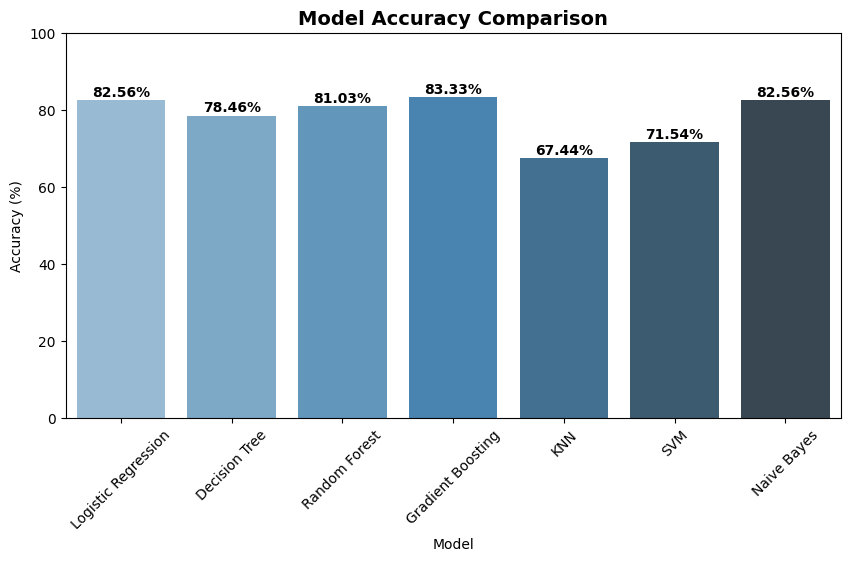

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Accuracy (%)', data=accuracy_df, palette='Blues_d')
plt.title('Model Accuracy Comparison', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(accuracy_df['Accuracy (%)']):
    plt.text(i, v + 1, f"{v}%", ha='center', fontsize=10, weight='bold')
plt.show()

## ## Thank you..pls upvote!!!!!